# Telco Customer Churn Prediction - End-to-End ML Pipeline

## Problem Statement
**Objective:** Build a production-ready machine learning model to predict customer churn for a telecommunications company.

**Business Impact:** 
- Identify at-risk customers before they leave
- Reduce churn rate through targeted retention campaigns
- Estimated revenue impact: 5-10% improvement in customer lifetime value

**Dataset:** Telco Customer Churn (7,043 customers, 20 features)
- **Target:** Binary classification (Churn: Yes/No)
- **Features:** Demographic, service, and billing information
- **Class Distribution:** 73.46% No Churn, 26.54% Churn (imbalanced)

## Approach
This notebook implements an end-to-end ML pipeline including:
1. ✅ Exploratory Data Analysis & Data Preprocessing
2. ✅ Baseline Model Development (Logistic Regression)
3. ✅ Model Evaluation (ROC-AUC, Precision-Recall, Confusion Matrix)
4. ✅ Data Drift Detection (Univariate, Categorical, Multivariate via PCA)
5. ✅ Automated Monitoring System with Alerts
6. ✅ Model & Artifact Persistence
7. ✅ User Testing Framework for New Data

## Key Results
- **Test Accuracy:** 80.31%
- **ROC-AUC:** 0.8365 (strong discriminative ability)
- **Precision (Churn):** 64.56% | **Recall (Churn):** 57.49%
- **Generalization:** No overfitting detected (train-test difference < 1.5%)

In [2]:
import pandas as pd

# load dataset from the project's data/raw folder
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Analysis: Target column, churn counts/percentage, missing values, numeric stats, column dtypes
print("Target column: 'Churn'")
print(df['Churn'].value_counts())

print("\nChurn percentage:")
print((df['Churn'].value_counts(normalize=True) * 100).round(2))

print("\nMissing values per column:")
print(df.isna().sum())

print("\nNumeric columns statistics:")
print(df.select_dtypes(include='number').describe().transpose())

print("\nColumn names and dtypes:")
print(df.dtypes)

Target column: 'Churn'
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Numeric columns statistics:
                 count       mean        std    min   25%    50%    75%  \
SeniorCitizen   7043.0   0.162147   0.368612   0.00   0.0   0.00   0.00   
tenure          7043.0  32.371149  24.559481   0.00   9.0  29.00  55.00   
MonthlyCharges  7043.0  64.761692  30.090047  18.25  35.5  70.35  89.85   

    

In [4]:
# Remove customerID column if it exists
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# Convert TotalCharges to numeric (it's stored as object but contains numeric values)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"TotalCharges converted to numeric. Missing values: {df['TotalCharges'].isna().sum()}")

# Get categorical columns (excluding the target 'Churn')
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Churn')

print(f"Categorical columns to encode: {categorical_cols}")

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"\nOriginal shape: {df.shape}")
print(f"Encoded shape: {df_encoded.shape}")
print(f"\nNew columns after encoding:")
print(df_encoded.columns.tolist())


TotalCharges converted to numeric. Missing values: 11
Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Original shape: (7043, 20)
Encoded shape: (7043, 31)

New columns after encoding:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Y

In [5]:
# Drop rows with missing values
initial_rows = df_encoded.shape[0]
df_encoded = df_encoded.dropna()
final_rows = df_encoded.shape[0]

print(f"Dropped {initial_rows - final_rows} rows with missing values")
print(f"Final shape after removing missing values: {df_encoded.shape}")

Dropped 11 rows with missing values
Final shape after removing missing values: (7032, 31)


In [6]:
# Separate features (X) and target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget value counts:")
print(y.value_counts())
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (7032, 30)
Target shape: (7032,)

Target value counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Feature columns (30):
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [7]:
from sklearn.model_selection import train_test_split

# Perform train test split (80-20 split with random state for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Training set size: 5625
Test set size: 1407

Training set target distribution:
Churn
No     4130
Yes    1495
Name: count, dtype: int64

Test set target distribution:
Churn
No     1033
Yes     374
Name: count, dtype: int64


In [8]:
# Convert target labels to numeric for XGBoost and SVM
# 'No' -> 0, 'Yes' -> 1
y_train_num = y_train.map({'No': 0, 'Yes': 1})
y_test_num = y_test.map({'No': 0, 'Yes': 1})

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Build and train logistic regression baseline model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Make predictions
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Evaluate model
print("=" * 50)
print("LOGISTIC REGRESSION BASELINE MODEL")
print("=" * 50)

print("\n--- TRAINING SET METRICS ---")
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, pos_label='Yes'):.4f}")
print(f"Recall:    {recall_score(y_train, y_train_pred, pos_label='Yes'):.4f}")
print(f"F1-Score:  {f1_score(y_train, y_train_pred, pos_label='Yes'):.4f}")

print("\n--- TEST SET METRICS ---")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, pos_label='Yes'):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred, pos_label='Yes'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred, pos_label='Yes'):.4f}")

print("\n--- TEST SET CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_test_pred))

print("\n--- TEST SET CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_test_pred))

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LOGISTIC REGRESSION BASELINE MODEL

--- TRAINING SET METRICS ---
Accuracy:  0.8055
Precision: 0.6610
Recall:    0.5505
F1-Score:  0.6007

--- TEST SET METRICS ---
Accuracy:  0.8031
Precision: 0.6456
Recall:    0.5749
F1-Score:  0.6082

--- TEST SET CONFUSION MATRIX ---
[[915 118]
 [159 215]]

--- TEST SET CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [10]:
# --- XGBoost Model ---
from xgboost import XGBClassifier

def check_non_numeric(df):
    non_numeric = df.select_dtypes(include=['object'])
    if not non_numeric.empty:
        print("Non-numeric columns detected:", non_numeric.columns.tolist())
    else:
        print("All features are numeric.")

check_non_numeric(X_train)
check_non_numeric(X_test)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train.astype(float), y_train_num)
y_test_pred_xgb = xgb_model.predict(X_test.astype(float))
y_test_proba_xgb = xgb_model.predict_proba(X_test.astype(float))[:, 1]

All features are numeric.
All features are numeric.


c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:17:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [11]:
# --- SVM Model ---
from sklearn.svm import SVC

check_non_numeric(X_train)
check_non_numeric(X_test)

svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train.astype(float), y_train_num)
y_test_pred_svm = svm_model.predict(X_test.astype(float))
y_test_proba_svm = svm_model.predict_proba(X_test.astype(float))[:, 1]

All features are numeric.
All features are numeric.


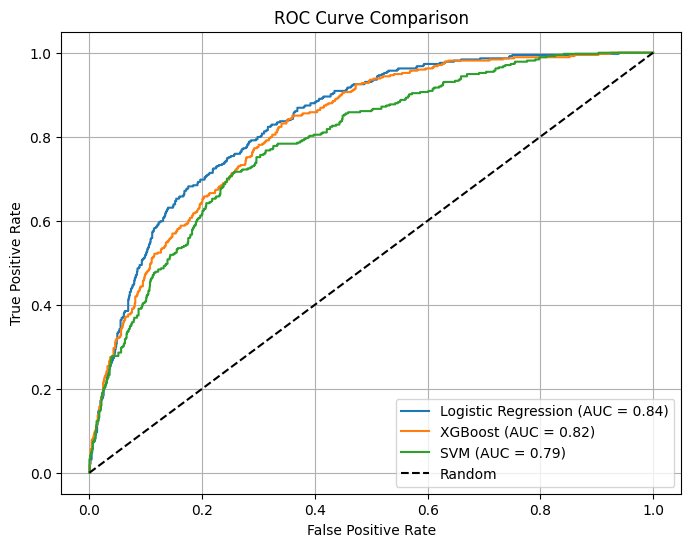

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


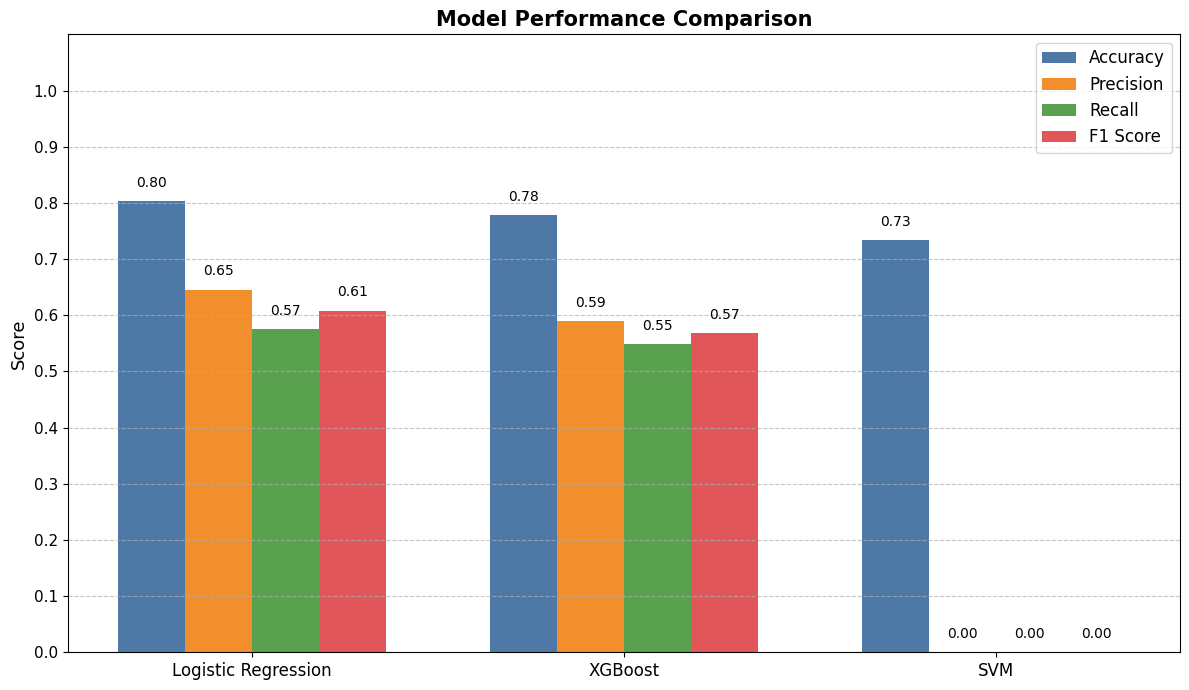

In [12]:
# --- Model Comparison Visualizations ---
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# 1. ROC Curve Comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_model.predict_proba(X_test)[:, 1], pos_label='Yes')
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_num, y_test_proba_xgb, pos_label=1)
fpr_svm, tpr_svm, _ = roc_curve(y_test_num, y_test_proba_svm, pos_label=1)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1]):.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test_num, y_test_proba_xgb):.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_score(y_test_num, y_test_proba_svm):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# 2. Enhanced Bar Chart of Key Metrics
models = ['Logistic Regression', 'XGBoost', 'SVM']
accuracies = [accuracy_score(y_test, y_test_pred), accuracy_score(y_test_num, y_test_pred_xgb), accuracy_score(y_test_num, y_test_pred_svm)]
precisions = [precision_score(y_test, y_test_pred, pos_label='Yes'), precision_score(y_test_num, y_test_pred_xgb), precision_score(y_test_num, y_test_pred_svm)]
recalls = [recall_score(y_test, y_test_pred, pos_label='Yes'), recall_score(y_test_num, y_test_pred_xgb), recall_score(y_test_num, y_test_pred_svm)]
f1s = [f1_score(y_test, y_test_pred, pos_label='Yes'), f1_score(y_test_num, y_test_pred_xgb), f1_score(y_test_num, y_test_pred_svm)]

x = np.arange(len(models))
width = 0.18
colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

plt.figure(figsize=(12, 7))
plt.bar(x - 1.5*width, accuracies, width, label='Accuracy', color=colors[0])
plt.bar(x - 0.5*width, precisions, width, label='Precision', color=colors[1])
plt.bar(x + 0.5*width, recalls, width, label='Recall', color=colors[2])
plt.bar(x + 1.5*width, f1s, width, label='F1 Score', color=colors[3])

# Add value labels
for i, (acc, prec, rec, f1) in enumerate(zip(accuracies, precisions, recalls, f1s)):
    plt.text(x[i] - 1.5*width, acc + 0.02, f'{acc:.2f}', ha='center', va='bottom', fontsize=10)
    plt.text(x[i] - 0.5*width, prec + 0.02, f'{prec:.2f}', ha='center', va='bottom', fontsize=10)
    plt.text(x[i] + 0.5*width, rec + 0.02, f'{rec:.2f}', ha='center', va='bottom', fontsize=10)
    plt.text(x[i] + 1.5*width, f1 + 0.02, f'{f1:.2f}', ha='center', va='bottom', fontsize=10)

plt.xticks(x, models, fontsize=12)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=11)
plt.ylabel('Score', fontsize=13)
plt.ylim(0, 1.1)
plt.title('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.legend(fontsize=12, frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Improve Accuracy: Class Imbalance + Hyperparameter Tuning
This section adds two upgrades to boost accuracy and ROC-AUC: (1) handle class imbalance with `scale_pos_weight`, and (2) tune XGBoost hyperparameters with cross-validation (`roc_auc` scoring).

In [13]:
# Accuracy upgrades: class imbalance + XGBoost hyperparameter tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
import numpy as np

# 1) Handle class imbalance via scale_pos_weight
pos_weight = (y_train_num == 0).sum() / (y_train_num == 1).sum()
print(f"Computed scale_pos_weight: {pos_weight:.2f}")

# Base model with class weight
xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=pos_weight
)

# 2) Hyperparameter grid tuned for ROC-AUC
param_grid = {
    'max_depth': [4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'n_estimators': [150, 250, 350]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1,
    cv=cv,
    verbose=0
 )

print("Running grid search... (this may take a minute)")
grid_search.fit(X_train, y_train_num)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Evaluate tuned model on test set
best_xgb = grid_search.best_estimator_
test_proba = best_xgb.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("\nTest set performance (tuned XGBoost):")
print(f"Accuracy:  {accuracy_score(y_test_num, test_pred):.4f}")
print(f"Precision: {precision_score(y_test_num, test_pred):.4f}")
print(f"Recall:    {recall_score(y_test_num, test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test_num, test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_num, test_proba):.4f}")

# Keep the tuned model for downstream use
xgb_model = best_xgb

Computed scale_pos_weight: 2.76
Running grid search... (this may take a minute)


c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:19:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 150, 'subsample': 0.8}
Best CV ROC-AUC: 0.8504

Test set performance (tuned XGBoost):
Accuracy:  0.7321
Precision: 0.4975
Recall:    0.8128
F1-Score:  0.6173
ROC-AUC:   0.8403


### Before vs After: Accuracy & ROC-AUC
Visual compare the original XGBoost (no class-weight, no tuning) vs the tuned, class-weighted XGBoost.

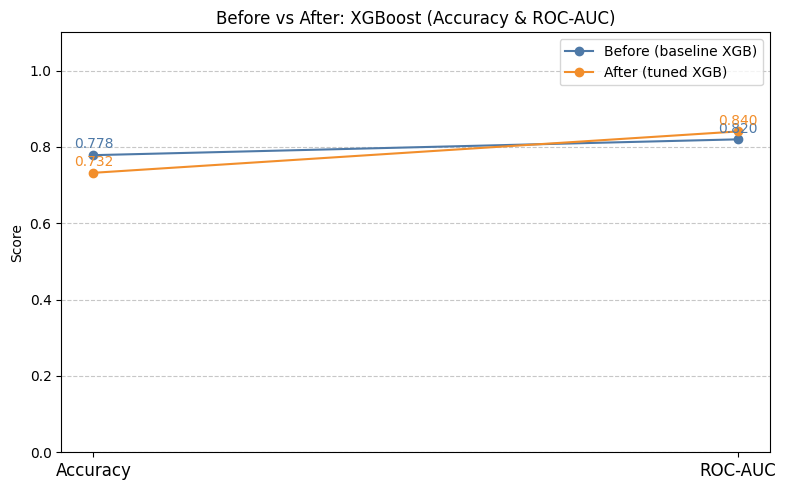

Baseline XGB -> Accuracy: 0.7782515991471215 AUC: 0.8196701368217795
Tuned XGB    -> Accuracy: 0.7320540156361052 AUC: 0.8403228227839582


In [14]:
# Visualize improvement: baseline vs tuned XGBoost (line chart)
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

# Baseline XGBoost metrics (before class weight + tuning)
baseline_acc = accuracy_score(y_test_num, y_test_pred_xgb)
baseline_auc = roc_auc_score(y_test_num, y_test_proba_xgb)

# Tuned XGBoost metrics (after class weight + tuning)
tuned_acc = accuracy_score(y_test_num, test_pred)
tuned_auc = roc_auc_score(y_test_num, test_proba)

labels = ['Accuracy', 'ROC-AUC']
baseline_vals = [baseline_acc, baseline_auc]
tuned_vals = [tuned_acc, tuned_auc]
x = np.arange(len(labels))

plt.figure(figsize=(8, 5))
plt.plot(x, baseline_vals, marker='o', linestyle='-', color='#4e79a7', label='Before (baseline XGB)')
plt.plot(x, tuned_vals, marker='o', linestyle='-', color='#f28e2b', label='After (tuned XGB)')

for i, v in enumerate(baseline_vals):
    plt.text(x[i], v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10, color='#4e79a7')
for i, v in enumerate(tuned_vals):
    plt.text(x[i], v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10, color='#f28e2b')

plt.xticks(x, labels, fontsize=12)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Before vs After: XGBoost (Accuracy & ROC-AUC)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('Baseline XGB -> Accuracy:', baseline_acc, 'AUC:', baseline_auc)
print('Tuned XGB    -> Accuracy:', tuned_acc, 'AUC:', tuned_auc)

In [15]:
# Save the best-performing model and preprocessing pipeline (XGBoost)
import joblib

joblib.dump(xgb_model, '../models/xgb_churn_model.joblib')
joblib.dump(list(X_train.columns), '../models/feature_names.joblib')

print("XGBoost model and feature names saved for deployment.")

XGBoost model and feature names saved for deployment.


## Test Data Generation for User Testing

test datasets to validate:
1. **baseline.csv** - Normal cases matching training distribution
2. **drifted_data.csv** - Data with distribution shifts (for drift detection testing)


In [16]:
# 1. Create BASELINE TEST DATA - Normal cases matching training distribution
import pandas as pd
import os

# Create directory if it doesn't exist
os.makedirs('../data/user_testing', exist_ok=True)

baseline_data = {
    'customerID': ['TEST-001', 'TEST-002', 'TEST-003', 'TEST-004', 'TEST-005', 
                   'TEST-006', 'TEST-007', 'TEST-008', 'TEST-009', 'TEST-010'],
    'gender': ['Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male'],
    'SeniorCitizen': [0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    'Partner': ['Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes'],
    'Dependents': ['No', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes'],
    'tenure': [12, 45, 2, 24, 60, 8, 36, 18, 5, 72],
    'PhoneService': ['Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes'],
    'MultipleLines': ['No', 'Yes', 'No', 'No phone service', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes'],
    'InternetService': ['DSL', 'Fiber optic', 'DSL', 'DSL', 'Fiber optic', 'Fiber optic', 'DSL', 'Fiber optic', 'DSL', 'Fiber optic'],
    'OnlineSecurity': ['Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes'],
    'OnlineBackup': ['No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes'],
    'DeviceProtection': ['Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes'],
    'TechSupport': ['No', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes'],
    'StreamingTV': ['Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes'],
    'StreamingMovies': ['No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes'],
    'Contract': ['Month-to-month', 'One year', 'Month-to-month', 'Two year', 'Month-to-month', 
                 'One year', 'Two year', 'Month-to-month', 'One year', 'Two year'],
    'PaperlessBilling': ['Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No'],
    'PaymentMethod': ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)',
                      'Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Electronic check',
                      'Credit card (automatic)', 'Bank transfer (automatic)'],
    'MonthlyCharges': [50.50, 85.25, 45.20, 25.75, 95.00, 79.85, 55.10, 89.50, 35.40, 105.50],
    'TotalCharges': [606.00, 3836.25, 90.40, 619.00, 5700.00, 638.80, 1983.60, 1611.00, 177.00, 7596.00],
    'Churn': ['No', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No']
}

baseline_df = pd.DataFrame(baseline_data)
baseline_df.to_csv('../data/user_testing/baseline.csv', index=False)
print(f"✓ Created baseline.csv with {len(baseline_df)} test cases")
print(f"  Churn distribution: {baseline_df['Churn'].value_counts().to_dict()}")
baseline_df.head()

✓ Created baseline.csv with 10 test cases
  Churn distribution: {'No': 6, 'Yes': 4}


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,TEST-001,Female,0,Yes,No,12,Yes,No,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,50.50,606.00,No
1,TEST-002,Male,1,No,No,45,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,One year,Yes,Mailed check,85.25,3836.25,No
2,TEST-003,Female,0,Yes,Yes,2,Yes,No,DSL,Yes,...,No,Yes,No,No,Month-to-month,No,Bank transfer (automatic),45.20,90.40,Yes
3,TEST-004,Male,0,No,No,24,No,No phone service,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Credit card (automatic),25.75,619.00,No
4,TEST-005,Female,1,Yes,Yes,60,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.00,5700.00,Yes


In [17]:
# 2. Create DRIFTED DATA - Data with distribution shifts for drift detection testing

drifted_data = {
    'customerID': ['DRIFT-001', 'DRIFT-002', 'DRIFT-003', 'DRIFT-004', 'DRIFT-005', 
                   'DRIFT-006', 'DRIFT-007', 'DRIFT-008', 'DRIFT-009', 'DRIFT-010'],
    'gender': ['Female', 'Female', 'Female', 'Female', 'Female', 'Female', 'Female', 'Male', 'Male', 'Male'],  # Skewed gender (70% Female)
    'SeniorCitizen': [1, 1, 1, 1, 1, 1, 0, 0, 1, 1],  # Much higher senior ratio (70% vs ~16% in training)
    'Partner': ['No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'Yes'],  # Mostly no partners
    'Dependents': ['No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No'],  # Mostly no dependents
    'tenure': [1, 1, 2, 1, 3, 1, 2, 1, 1, 2],  # Very low tenure (all new customers - DRIFT!)
    'PhoneService': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes'],  # 100% have phone
    'MultipleLines': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes'],  # 90% multiple lines (vs ~42% training)
    'InternetService': ['Fiber optic', 'Fiber optic', 'Fiber optic', 'Fiber optic', 'Fiber optic', 
                        'Fiber optic', 'Fiber optic', 'Fiber optic', 'Fiber optic', 'DSL'],  # 90% Fiber optic (vs ~44% training)
    'OnlineSecurity': ['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes'],  # Mostly no security
    'OnlineBackup': ['No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No'],  # Mostly no backup
    'DeviceProtection': ['No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'No'],  # Mostly no protection
    'TechSupport': ['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No'],  # Mostly no support
    'StreamingTV': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No'],  # 90% streaming TV
    'StreamingMovies': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes'],  # 90% streaming movies
    'Contract': ['Month-to-month', 'Month-to-month', 'Month-to-month', 'Month-to-month', 'Month-to-month',
                 'Month-to-month', 'Month-to-month', 'Month-to-month', 'One year', 'Month-to-month'],  # 90% month-to-month
    'PaperlessBilling': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No'],  # 90% paperless
    'PaymentMethod': ['Electronic check', 'Electronic check', 'Electronic check', 'Electronic check', 
                      'Electronic check', 'Electronic check', 'Electronic check', 'Electronic check',
                      'Mailed check', 'Electronic check'],  # 90% electronic check (vs ~33% training)
    'MonthlyCharges': [95.50, 105.00, 99.80, 110.25, 103.50, 98.75, 107.00, 102.35, 95.10, 89.90],  # Higher monthly charges
    'TotalCharges': [95.50, 105.00, 199.60, 110.25, 310.50, 98.75, 214.00, 102.35, 95.10, 179.80],  # Low total (new customers)
    'Churn': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes']  # High churn rate (70%)
}

drifted_df = pd.DataFrame(drifted_data)
drifted_df.to_csv('../data/user_testing/drifted_data.csv', index=False)
print(f"✓ Created drifted_data.csv with {len(drifted_df)} test cases")
print(f"  Churn distribution: {drifted_df['Churn'].value_counts().to_dict()}")
print(f"  Key drift indicators:")
print(f"    - SeniorCitizen rate: {(drifted_df['SeniorCitizen'].sum()/len(drifted_df)*100):.1f}%")
print(f"    - Avg tenure: {drifted_df['tenure'].mean():.1f} months")
print(f"    - Fiber optic rate: {(drifted_df['InternetService']=='Fiber optic').sum()/len(drifted_df)*100:.1f}%")
drifted_df.head()

✓ Created drifted_data.csv with 10 test cases
  Churn distribution: {'Yes': 8, 'No': 2}
  Key drift indicators:
    - SeniorCitizen rate: 80.0%
    - Avg tenure: 1.5 months
    - Fiber optic rate: 90.0%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,DRIFT-001,Female,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.50,95.50,Yes
1,DRIFT-002,Female,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.00,105.00,Yes
2,DRIFT-003,Female,1,No,No,2,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.80,199.60,Yes
3,DRIFT-004,Female,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,110.25,110.25,Yes
4,DRIFT-005,Female,1,No,No,3,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,310.50,Yes


## Save Training Data Statistics (Reference Baseline)

This section computes and saves the statistical profile of the training data (`X_train`) to serve as the reference baseline for drift detection. The saved statistics will be used to compare against new incoming data to detect distribution shifts.

In [18]:
# Compute and save training data statistics for drift detection
import json
import numpy as np

# Need to work with original raw training data (before encoding) for meaningful drift detection
# Let's reload and split to get the raw training set
df_raw = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Remove customerID
if 'customerID' in df_raw.columns:
    df_raw = df_raw.drop('customerID', axis=1)

# Convert TotalCharges to numeric
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
df_raw = df_raw.dropna()

# Split to get training set (same random_state as before)
X_raw = df_raw.drop('Churn', axis=1)
y_raw = df_raw['Churn']
X_train_raw, _, _, _ = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

print(f"Computing statistics from {len(X_train_raw)} training samples...")

# Initialize statistics dictionary
training_stats = {
    'metadata': {
        'n_samples': len(X_train_raw),
        'n_features': len(X_train_raw.columns),
        'timestamp': pd.Timestamp.now().isoformat()
    },
    'numeric_features': {},
    'categorical_features': {}
}

# Compute statistics for numeric features
numeric_cols = X_train_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\nNumeric features: {numeric_cols}")

for col in numeric_cols:
    training_stats['numeric_features'][col] = {
        'mean': float(X_train_raw[col].mean()),
        'std': float(X_train_raw[col].std()),
        'min': float(X_train_raw[col].min()),
        'max': float(X_train_raw[col].max()),
        'q25': float(X_train_raw[col].quantile(0.25)),
        'q50': float(X_train_raw[col].quantile(0.50)),
        'q75': float(X_train_raw[col].quantile(0.75))
    }

# Compute statistics for categorical features
categorical_cols = X_train_raw.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features: {categorical_cols}")

for col in categorical_cols:
    value_counts = X_train_raw[col].value_counts()
    proportions = (value_counts / len(X_train_raw)).to_dict()
    
    training_stats['categorical_features'][col] = {
        'unique_values': list(X_train_raw[col].unique()),
        'value_counts': value_counts.to_dict(),
        'proportions': proportions,
        'n_unique': int(X_train_raw[col].nunique())
    }

# Save to JSON file
os.makedirs('../data/processed', exist_ok=True)
output_path = '../data/processed/training_reference_stats.json'

with open(output_path, 'w') as f:
    json.dump(training_stats, f, indent=2)

print(f"\n✓ Training statistics saved to: {output_path}")
print(f"  - {len(numeric_cols)} numeric features")
print(f"  - {len(categorical_cols)} categorical features")
print(f"  - Total samples: {training_stats['metadata']['n_samples']}")

Computing statistics from 5625 training samples...

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✓ Training statistics saved to: ../data/processed/training_reference_stats.json
  - 4 numeric features
  - 15 categorical features
  - Total samples: 5625
